<a href="https://colab.research.google.com/github/Victor1e/Project_Rumelhart_Romanian/blob/main/Varianta_cu_imperfect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


DATASET PREGATIT

Total exemple: 15050
  Verbe generate: 14000 (din 2000 verbe × 7 forme)
  Verbe reale (×5): 1050

Exemple din dataset:
  foi|PART               → foit
  tuza|PART              → tuzat
  suce|IMP1              → suceam
  snaea|IMP6             → snaeau
  duce|IMP1              → duceam
  inmai|IMP1             → inmaeam
  tivaa|IMP5             → tivaați
  blahebie|IMP4          → blahebiam
  mejce|IMP3             → mejcea
  dia|IMP3               → dia

Caractere în vocabular (36): 123456AIMPRTabcdefghijklmnoprstuvz|ț

Train: 12792 | Test: 2258


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


ANTRENAMENT

Epoch 1/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 64s 654ms/step - accuracy: 0.6539 - loss: 1.5095 - val_accuracy: 0.7564 - val_loss: 0.8309 - learning_rate: 0.0010
Epoch 2/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 56s 657ms/step - accuracy: 0.7759 - loss: 0.7569 - val_accuracy: 0.9028 - val_loss: 0.3406 - learning_rate: 0.0010
Epoch 3/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 81s 644ms/step - accuracy: 0.9243 - loss: 0.2633 - val_accuracy: 0.9917 - val_loss: 0.0512 - learning_rate: 0.0010
Epoch 4/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 55s 652ms/step - accuracy: 0.9899 - loss: 0.0515 - val_accuracy: 0.9950 - val_loss: 0.0236 - learning_rate: 0.0010
Epoch 5/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 54s 636ms/step - accuracy: 0.9947 - loss: 0.0241 - val_accuracy: 0.9967 - val_loss: 0.0163 - learning_rate: 0.0010
Epoch 6/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 84s 666ms/step - accuracy: 0.9960 - loss: 0.0176 - val_accuracy: 0.9976 - val_loss: 0.0114 - learning_rate: 0.0010
Epoch 7/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 54s 637ms/step - accura

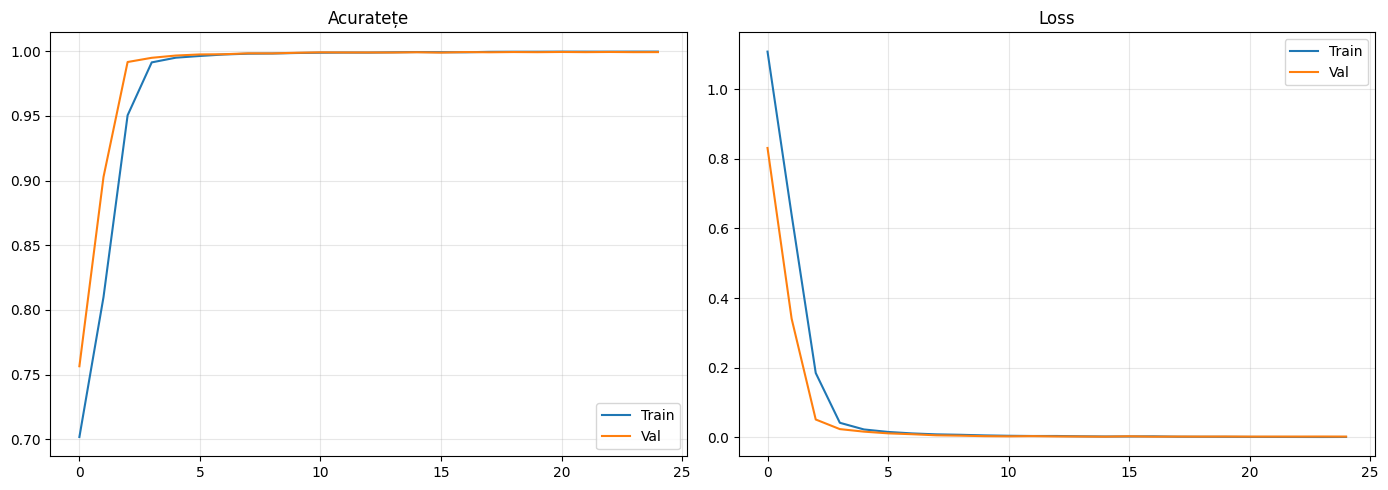


TESTE

Acuratețe test: 99.94%

  LUCRA

  Participiu: lucrat

  IMPERFECT:
    eu           lucram
    tu           lucrai
    el/ea        lucra
    noi          lucram
    voi          lucrați
    ei/ele       lucrau

  VEDEA

  Participiu: vezut

  IMPERFECT:
    eu           vedeam
    tu           vedeai
    el/ea        vedea
    noi          vedeam
    voi          vedeați
    ei/ele       vedeau

  MERGE

  Participiu: mers

  IMPERFECT:
    eu           mergeam
    tu           mergeai
    el/ea        mergea
    noi          mergeam
    voi          mergeați
    ei/ele       mergeau

  DORMI

  Participiu: dormit

  IMPERFECT:
    eu           dormeam
    tu           dormeai
    el/ea        dormea
    noi          dormeam
    voi          dormeați
    ei/ele       dormeau

  DUCE

  Participiu: dus

  IMPERFECT:
    eu           duceam
    tu           duceai
    el/ea        ducea
    noi          duceam
    voi          duceați
    ei/ele       duceau

  SPUNE

  Partici

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding, Bidirectional, TimeDistributed, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import random

PERSOANE = ["eu", "tu", "el/ea", "noi", "voi", "ei/ele"]

def genereaza_verbe_regulate(n=2000):
    """
    Generează verbe cu: participiu + imperfect (6 persoane)
    Total: 7 forme per verb → 2000 verbe × 7 = 14000 exemple
    """
    consoane_simple = list("bcdfghjklmnprstvz")
    consoane_duble = ["tr", "pr", "br", "dr", "gr", "cr", "fr", "pl", "bl", "cl", "fl", "gl",
                      "st", "sp", "sc", "str", "spr", "scr", "sm", "sn", "sl"]
    vocale = list("aeiou")

    silabe_start = ["a", "ba", "ca", "da", "de", "di", "do", "fa", "ga", "ha", "in", "la",
                    "ma", "na", "pa", "pe", "pi", "po", "pre", "pri", "pro", "ra", "re",
                    "sa", "se", "si", "so", "su", "ta", "te", "ti", "tra", "tri", "va", "ve", "za"]
    silabe_mid = ["ba", "be", "bi", "bo", "bu", "ca", "ce", "ci", "co", "cu", "da", "de",
                  "di", "do", "du", "fa", "fe", "fi", "fo", "fu", "ga", "ge", "gi", "go",
                  "gu", "la", "le", "li", "lo", "lu", "ma", "me", "mi", "mo", "mu", "na",
                  "ne", "ni", "no", "nu", "pa", "pe", "pi", "po", "pu", "ra", "re", "ri",
                  "ro", "ru", "sa", "se", "si", "so", "su", "ta", "te", "ti", "to", "tu",
                  "va", "ve", "vi", "vo", "vu", "za", "ze", "zi", "zo", "zu"]

    # (terminație_inf, participiu, imperfect[6 pers])
    conjugari = [
        ("a", "at", ["am", "ai", "a", "am", "ați", "au"], 0.30),
        ("ea", "ut", ["eam", "eai", "ea", "eam", "eați", "eau"], 0.15),
        ("e", "ut", ["eam", "eai", "ea", "eam", "eați", "eau"], 0.12),
        ("ge", "s", ["geam", "geai", "gea", "geam", "geați", "geau"], 0.08),
        ("ie", "is", ["iam", "iai", "ia", "iam", "iați", "iau"], 0.08),
        ("i", "it", ["eam", "eai", "ea", "eam", "eați", "eau"], 0.15),
        ("ce", "s", ["ceam", "ceai", "cea", "ceam", "ceați", "ceau"], 0.06),
        ("ne", "s", ["neam", "neai", "nea", "neam", "neați", "neau"], 0.06),
    ]

    verbe = []
    verbe_unice = set()

    while len(verbe_unice) < n:
        if random.random() < 0.7:
            nr_silabe = random.randint(1, 3)
            radacina = random.choice(silabe_start)
            for _ in range(nr_silabe - 1):
                radacina += random.choice(silabe_mid)
        else:
            lungime = random.randint(2, 5)
            radacina = ""
            for i in range(lungime):
                if i % 2 == 0:
                    if random.random() < 0.2 and i == 0:
                        radacina += random.choice(consoane_duble)
                    else:
                        radacina += random.choice(consoane_simple)
                else:
                    radacina += random.choice(vocale)

        r = random.random()
        cumsum = 0
        for term_inf, term_part, imperf, prob in conjugari:
            cumsum += prob
            if r < cumsum:
                infinitiv = radacina + term_inf
                if infinitiv in verbe_unice:
                    break
                verbe_unice.add(infinitiv)

                # Participiu
                verbe.append((f"{infinitiv}|PART", radacina + term_part))
                # Imperfect: 6 persoane
                for i in range(6):
                    verbe.append((f"{infinitiv}|IMP{i+1}", radacina + imperf[i]))
                break

    return verbe, verbe_unice

# Verbe reale cu participiu + imperfect (6 persoane)
verbe_reale = [
    {"inf": "lucra", "part": "lucrat", "imp": ["lucram", "lucrai", "lucra", "lucram", "lucrați", "lucrau"]},
    {"inf": "canta", "part": "cantat", "imp": ["cantam", "cantai", "canta", "cantam", "cantați", "cantau"]},
    {"inf": "manca", "part": "mancat", "imp": ["mancam", "mancai", "manca", "mancam", "mancați", "mancau"]},
    {"inf": "juca", "part": "jucat", "imp": ["jucam", "jucai", "juca", "jucam", "jucați", "jucau"]},
    {"inf": "pleca", "part": "plecat", "imp": ["plecam", "plecai", "pleca", "plecam", "plecați", "plecau"]},
    {"inf": "intra", "part": "intrat", "imp": ["intram", "intrai", "intra", "intram", "intrați", "intrau"]},
    {"inf": "lua", "part": "luat", "imp": ["luam", "luai", "lua", "luam", "luați", "luau"]},
    {"inf": "da", "part": "dat", "imp": ["dadeam", "dadeai", "dadea", "dadeam", "dadeați", "dadeau"]},

    {"inf": "vedea", "part": "vazut", "imp": ["vedeam", "vedeai", "vedea", "vedeam", "vedeați", "vedeau"]},
    {"inf": "avea", "part": "avut", "imp": ["aveam", "aveai", "avea", "aveam", "aveați", "aveau"]},
    {"inf": "cadea", "part": "cazut", "imp": ["cadeam", "cadeai", "cadea", "cadeam", "cadeați", "cadeau"]},
    {"inf": "putea", "part": "putut", "imp": ["puteam", "puteai", "putea", "puteam", "puteați", "puteau"]},
    {"inf": "placea", "part": "placut", "imp": ["placeam", "placeai", "placea", "placeam", "placeați", "placeau"]},

    {"inf": "crede", "part": "crezut", "imp": ["credeam", "credeai", "credea", "credeam", "credeați", "credeau"]},
    {"inf": "merge", "part": "mers", "imp": ["mergeam", "mergeai", "mergea", "mergeam", "mergeați", "mergeau"]},
    {"inf": "scrie", "part": "scris", "imp": ["scriam", "scriai", "scria", "scriam", "scriați", "scriau"]},
    {"inf": "zice", "part": "zis", "imp": ["ziceam", "ziceai", "zicea", "ziceam", "ziceați", "ziceau"]},
    {"inf": "face", "part": "facut", "imp": ["faceam", "faceai", "facea", "faceam", "faceați", "faceau"]},
    {"inf": "trage", "part": "tras", "imp": ["trageam", "trageai", "tragea", "trageam", "trageați", "trageau"]},

    {"inf": "dormi", "part": "dormit", "imp": ["dormeam", "dormeai", "dormea", "dormeam", "dormeați", "dormeau"]},
    {"inf": "veni", "part": "venit", "imp": ["veneam", "veneai", "venea", "veneam", "veneați", "veneau"]},
    {"inf": "fugi", "part": "fugit", "imp": ["fugeam", "fugeai", "fugea", "fugeam", "fugeați", "fugeau"]},
    {"inf": "citi", "part": "citit", "imp": ["citeam", "citeai", "citea", "citeam", "citeați", "citeau"]},
    {"inf": "iubi", "part": "iubit", "imp": ["iubeam", "iubeai", "iubea", "iubeam", "iubeați", "iubeau"]},
    {"inf": "auzi", "part": "auzit", "imp": ["auzeam", "auzeai", "auzea", "auzeam", "auzeați", "auzeau"]},

    {"inf": "duce", "part": "dus", "imp": ["duceam", "duceai", "ducea", "duceam", "duceați", "duceau"]},
    {"inf": "aduce", "part": "adus", "imp": ["aduceam", "aduceai", "aducea", "aduceam", "aduceați", "aduceau"]},
    {"inf": "spune", "part": "spus", "imp": ["spuneam", "spuneai", "spunea", "spuneam", "spuneați", "spuneau"]},
    {"inf": "pune", "part": "pus", "imp": ["puneam", "puneai", "punea", "puneam", "puneați", "puneau"]},
    {"inf": "ajunge", "part": "ajuns", "imp": ["ajungeam", "ajungeai", "ajungea", "ajungeam", "ajungeați", "ajungeau"]},
]

def verbe_reale_to_dataset(verbe_reale_list):
    dataset = []
    for v in verbe_reale_list:
        dataset.append((f"{v['inf']}|PART", v['part']))
        for i in range(6):
            dataset.append((f"{v['inf']}|IMP{i+1}", v['imp'][i]))
    return dataset

# Dataset: 2000 verbe × 7 forme = 14000 + verbe reale
verbe_generate, verbe_unice = genereaza_verbe_regulate(2000)
verbe_reale_dataset = verbe_reale_to_dataset(verbe_reale) * 5
dataset = verbe_generate + verbe_reale_dataset
random.shuffle(dataset)

print()
print(f"DATASET PREGATIT")
print()
print(f"Total exemple: {len(dataset)}")
print(f"  Verbe generate: {len(verbe_generate)} (din {len(verbe_unice)} verbe × 7 forme)")
print(f"  Verbe reale (×5): {len(verbe_reale_dataset)}")
print(f"\nExemple din dataset:")
for inp, out in random.sample(dataset, 10):
    print(f"  {inp:22} → {out}")

all_text = "".join([x[0] + x[1] for x in dataset])
chars = sorted(list(set(all_text)))
print(f"\nCaractere în vocabular ({len(chars)}): {''.join(chars)}")

char_to_int = {c: i+2 for i, c in enumerate(chars)}
char_to_int['<PAD>'] = 0
char_to_int['<UNK>'] = 1
int_to_char = {i: c for c, i in char_to_int.items()}

vocab_size = len(char_to_int)
max_len = 20

def encode_word(word):
    return [char_to_int.get(c, 1) for c in word]

X = pad_sequences([encode_word(p[0]) for p in dataset], maxlen=max_len, padding='post')
Y = pad_sequences([encode_word(p[1]) for p in dataset], maxlen=max_len, padding='post')
Y_onehot = to_categorical(Y, num_classes=vocab_size)

X_train, X_test, y_train, y_test = train_test_split(X, Y_onehot, test_size=0.15, random_state=42)

print(f"\nTrain: {len(X_train)} | Test: {len(X_test)}")

model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len))
model.add(Bidirectional(LSTM(256, return_sequences=True)))
model.add(Dropout(0.4))
model.add(Bidirectional(LSTM(128, return_sequences=True)))
model.add(Dropout(0.3))
model.add(TimeDistributed(Dense(vocab_size, activation='softmax')))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.0001)
]

print()
print("ANTRENAMENT")
print()
history = model.fit(X_train, y_train, epochs=100, batch_size=128, validation_split=0.15, callbacks=callbacks, verbose=1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Acuratețe')
plt.legend()
plt.grid(True, alpha=0.3)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

def predict_verb(word, cod="PART"):
    inp = f"{word}|{cod}"
    vec = pad_sequences([encode_word(inp)], maxlen=max_len, padding='post')
    pred = model.predict(vec, verbose=0)
    res = ""
    for i in range(max_len):
        idx = np.argmax(pred[0][i])
        if idx > 1:
            res += int_to_char[idx]
    return res

def conjugare_completa(verb):
    print()
    print(f"  {verb.upper()}")
    print()
    print(f"  Participiu: {predict_verb(verb, 'PART')}")
    print(f"\n  IMPERFECT:")
    for i, pers in enumerate(PERSOANE):
        print(f"    {pers:12} {predict_verb(verb, f'IMP{i+1}')}")

print()
print("TESTE")
print()

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Acuratețe test: {test_acc*100:.2f}%")

for verb in ["lucra", "vedea", "merge", "dormi", "duce", "spune"]:
    conjugare_completa(verb)

print()
print("GENERALIZARE - VERBE INVENTATE")
print()
for v in ["blurpa", "tramea", "florge", "snorpi","boganiza"]:
    conjugare_completa(v)